## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)


## 2. Load the Dataset

In [2]:
df = pd.read_csv('heart_disease_uci.csv')
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [4]:
# Quick look at missing values in each column
df.isnull().sum().sort_values(ascending=False)


ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
exang        55
thalch       55
chol         30
restecg       2
cp            0
dataset       0
id            0
age           0
sex           0
num           0
dtype: int64

The dataset has quite a few missing values, especially in `ca`, `thal` and `slope`. It also
combines patients from 4 different hospitals (Cleveland, Hungary, Switzerland, VA Long Beach), which
is likely why so much data is missing - not every hospital recorded every test.

The `num` column is the original target and ranges from 0 (no disease) to 4 (different severity levels
of disease). For this project we only care about presence vs absence of heart disease, so it will be
converted into a binary target.

## 3. Data Cleaning & Target Creation

In [5]:
# id column is just a row identifier, not useful for modeling
df = df.drop(columns=['id'])

# Convert target to binary: 0 = no heart disease, 1 = heart disease present (any severity)
df['target'] = (df['num'] > 0).astype(int)
df = df.drop(columns=['num'])

df['target'].value_counts()


target
1    509
0    411
Name: count, dtype: int64

In [6]:
# Fill missing numeric columns with median (robust to outliers)
numeric_cols = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical columns with the most frequent value (mode)
categorical_cols = ['fbs', 'restecg', 'exang', 'slope', 'thal']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


In [7]:
# fbs and exang are stored as TRUE/FALSE strings, convert to 0/1
df['fbs'] = df['fbs'].astype(str).map({'TRUE': 1, 'FALSE': 0})
df['exang'] = df['exang'].astype(str).map({'TRUE': 1, 'FALSE': 0})
df[['fbs', 'exang']].head()


,fbs,exang
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


## 4. Exploratory Data Analysis

C:\Users\dell\AppData\Local\Temp\ipykernel_3528\2976329530.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


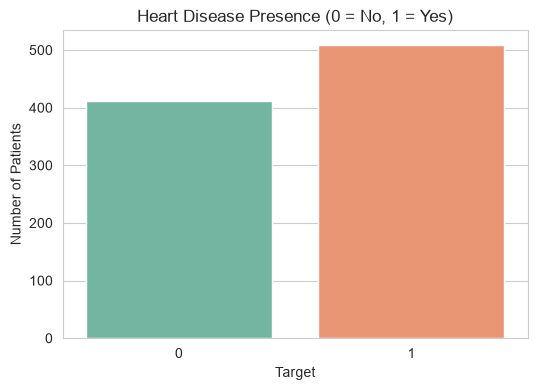

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Heart Disease Presence (0 = No, 1 = Yes)')
plt.xlabel('Target')
plt.ylabel('Number of Patients')
plt.show()


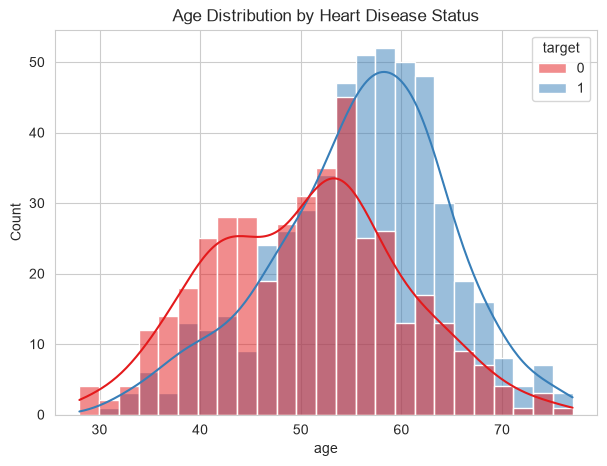

In [9]:
plt.figure(figsize=(7,5))
sns.histplot(data=df, x='age', hue='target', kde=True, bins=25, palette='Set1')
plt.title('Age Distribution by Heart Disease Status')
plt.show()


C:\Users\dell\AppData\Local\Temp\ipykernel_3528\1876799975.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='chol', data=df, palette='Set3')


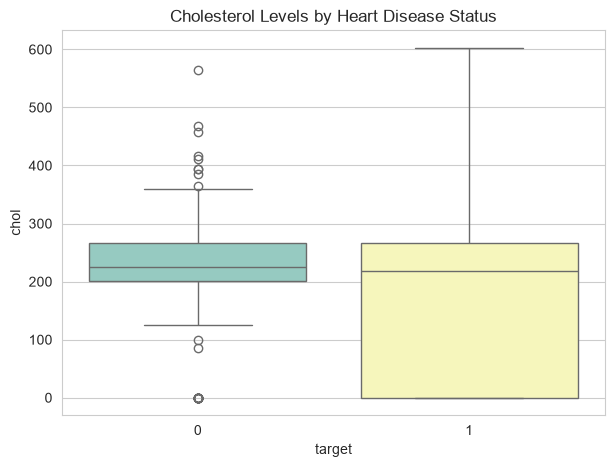

In [10]:
plt.figure(figsize=(7,5))
sns.boxplot(x='target', y='chol', data=df, palette='Set3')
plt.title('Cholesterol Levels by Heart Disease Status')
plt.show()


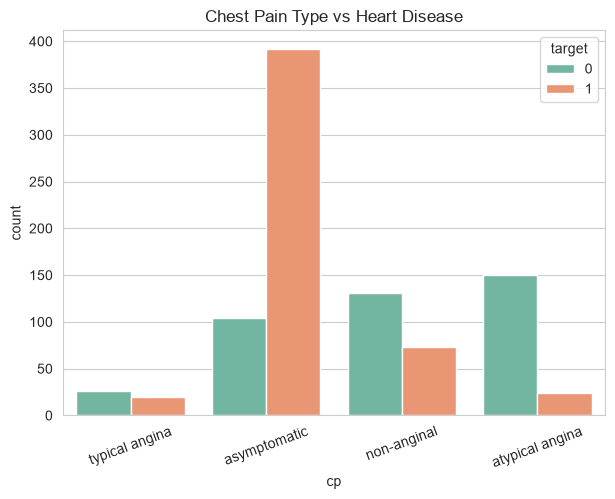

In [11]:
plt.figure(figsize=(7,5))
sns.countplot(x='cp', hue='target', data=df, palette='Set2')
plt.title('Chest Pain Type vs Heart Disease')
plt.xticks(rotation=20)
plt.show()


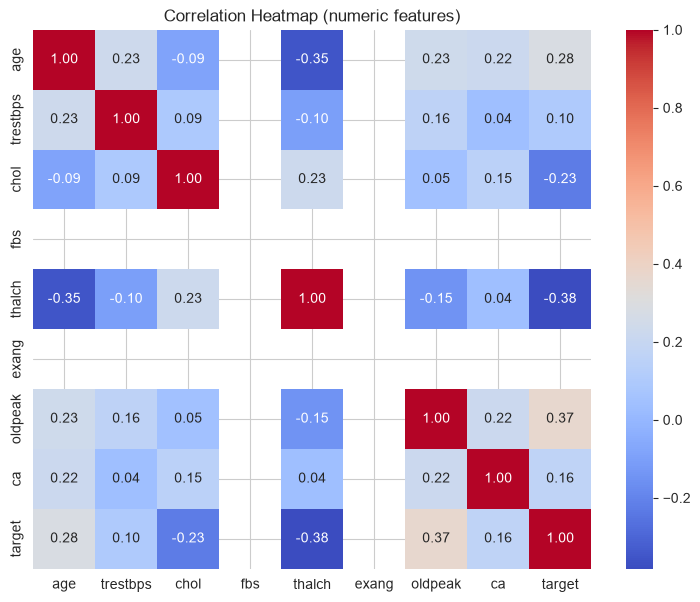

In [12]:
plt.figure(figsize=(9,7))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap (numeric features)')
plt.show()


From the plots above:
- Heart disease becomes more common with age, especially past 50.
- Patients with heart disease tend to have a lower max heart rate achieved (`thalch`) and higher `oldpeak`.
- `cp` (chest pain type) looks like a strong indicator - asymptomatic patients show up much more often in the disease group, which matches medical intuition (silent/asymptomatic cases are often more serious).

## 5. Encoding Categorical Variables

In [13]:
# One-hot encode remaining categorical (text) columns
df_encoded = pd.get_dummies(df, columns=['sex', 'dataset', 'cp', 'restecg', 'slope', 'thal'], drop_first=True)

X = df_encoded.drop(columns=['target'])
y = df_encoded['target']

print("Final feature count:", X.shape[1])
X.head()


Final feature count: 21


,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,sex_Male,dataset_Hungary,...,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,NaN,150.0,NaN,2.3,0.0,True,False,...,False,False,False,True,False,False,False,False,False,False
1,67,160.0,286.0,NaN,108.0,NaN,1.5,3.0,True,False,...,False,False,False,False,False,False,True,False,True,False
2,67,120.0,229.0,NaN,129.0,NaN,2.6,2.0,True,False,...,False,False,False,False,False,False,True,False,False,True
3,37,130.0,250.0,NaN,187.0,NaN,3.5,0.0,True,False,...,False,False,True,False,True,False,False,False,True,False
4,41,130.0,204.0,NaN,172.0,NaN,1.4,0.0,False,False,...,False,True,False,False,False,False,False,True,True,False


## 6. Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 736
Testing samples: 184


## 7. Decision Tree Classifier

In [15]:
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy :", accuracy_score(y_test, dt_pred))
print("Decision Tree Precision:", precision_score(y_test, dt_pred))
print("Decision Tree Recall   :", recall_score(y_test, dt_pred))
print("\nClassification Report:\n", classification_report(y_test, dt_pred))


Decision Tree Accuracy : 0.8097826086956522
Decision Tree Precision: 0.7815126050420168
Decision Tree Recall   : 0.9117647058823529

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.68      0.76        82
           1       0.78      0.91      0.84       102

    accuracy                           0.81       184
   macro avg       0.82      0.80      0.80       184
weighted avg       0.82      0.81      0.81       184



### Visualizing the Decision Tree
Depth was limited to 4 so the tree stays readable and doesn't overfit.

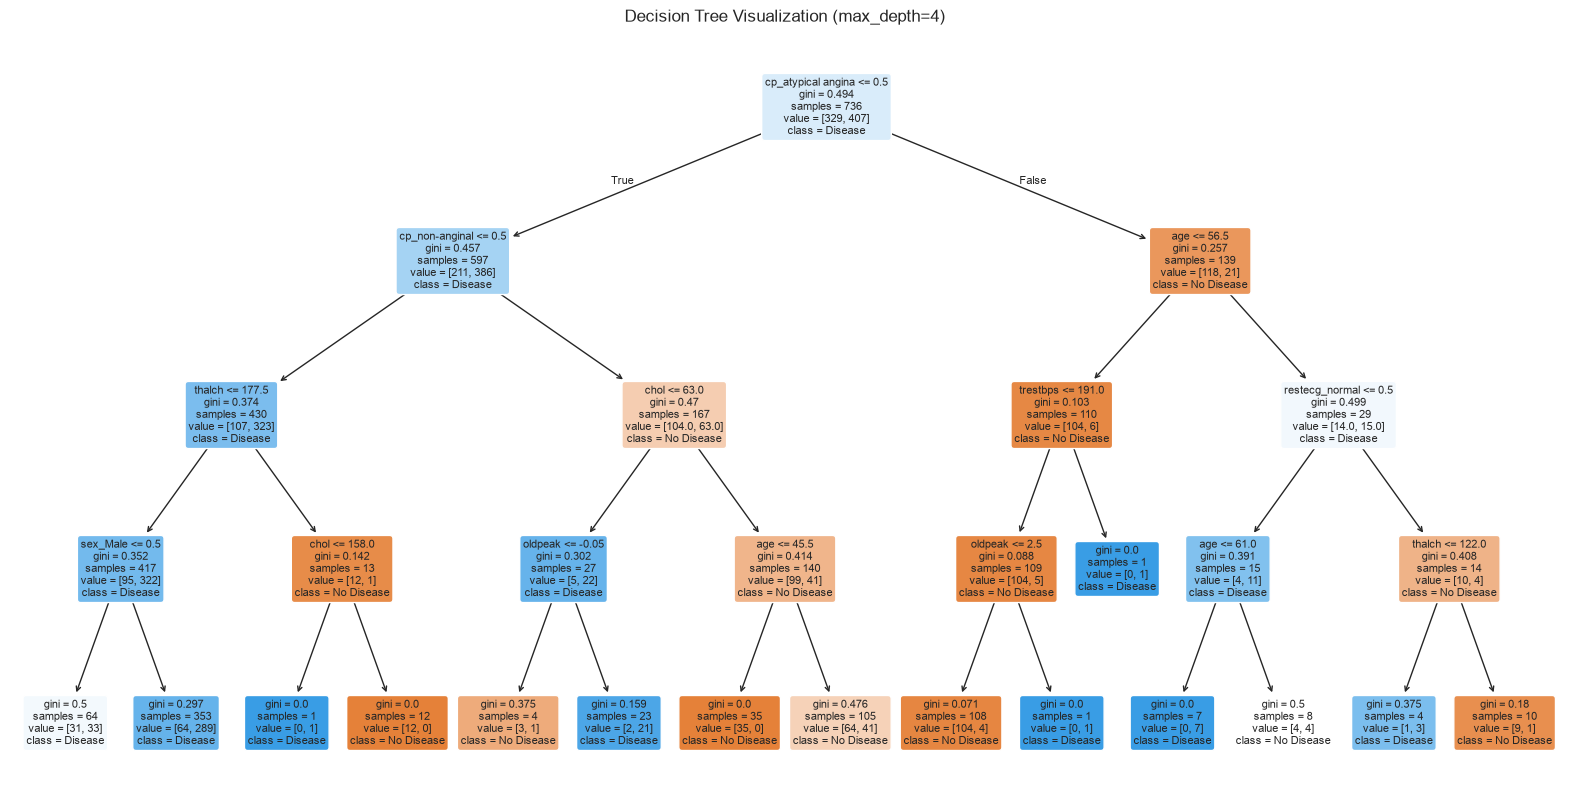

In [16]:
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=X.columns, class_names=['No Disease', 'Disease'],
          filled=True, rounded=True, fontsize=8)
plt.title('Decision Tree Visualization (max_depth=4)')
plt.show()


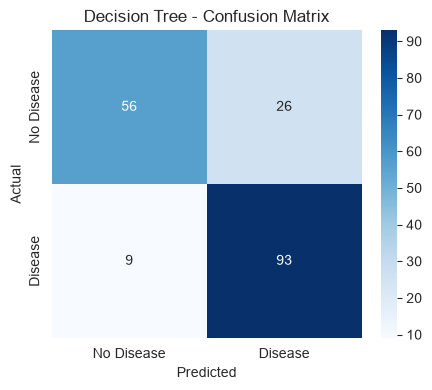

In [17]:
cm_dt = confusion_matrix(y_test, dt_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease','Disease'], yticklabels=['No Disease','Disease'])
plt.title('Decision Tree - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## 8. Random Forest Classifier

In [18]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy :", accuracy_score(y_test, rf_pred))
print("Random Forest Precision:", precision_score(y_test, rf_pred))
print("Random Forest Recall   :", recall_score(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))


Random Forest Accuracy : 0.8478260869565217
Random Forest Precision: 0.8303571428571429
Random Forest Recall   : 0.9117647058823529

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.77      0.82        82
           1       0.83      0.91      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184



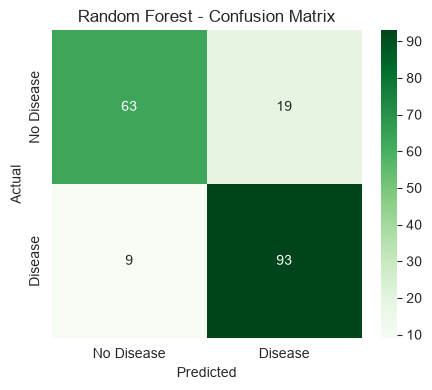

In [19]:
cm_rf = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Disease','Disease'], yticklabels=['No Disease','Disease'])
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## 9. Comparing Single Tree vs Random Forest

In [20]:
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, dt_pred), accuracy_score(y_test, rf_pred)],
    'Precision': [precision_score(y_test, dt_pred), precision_score(y_test, rf_pred)],
    'Recall': [recall_score(y_test, dt_pred), recall_score(y_test, rf_pred)],
    'F1-Score': [f1_score(y_test, dt_pred), f1_score(y_test, rf_pred)]
})
results


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.809783,0.781513,0.911765,0.841629
1,Random Forest,0.847826,0.830357,0.911765,0.869159


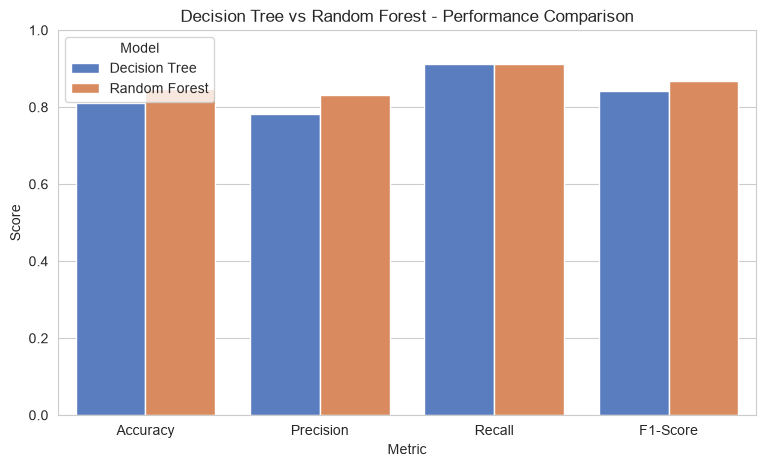

In [21]:
results_melted = results.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(9,5))
sns.barplot(x='Metric', y='Score', hue='Model', data=results_melted, palette='muted')
plt.title('Decision Tree vs Random Forest - Performance Comparison')
plt.ylim(0, 1)
plt.show()


The Random Forest outperforms the single Decision Tree across all metrics. This makes sense - a
single tree can overfit or make mistakes based on a few splits, while the forest averages predictions
from many trees (each trained on a random subset of data/features), which reduces variance and makes
the model more robust to noise in the data.

## 10. Feature Importance (Random Forest)

C:\Users\dell\AppData\Local\Temp\ipykernel_3528\3500336219.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values[:15], y=importances.index[:15], palette='viridis')


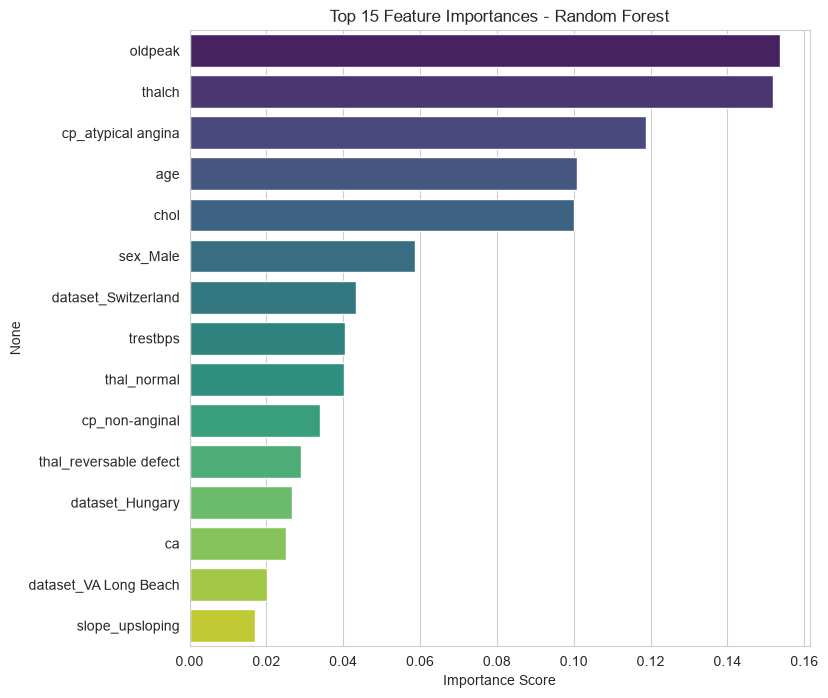

oldpeak                   0.153663
thalch                    0.151854
cp_atypical angina        0.118822
age                       0.100760
chol                      0.099975
sex_Male                  0.058618
dataset_Switzerland       0.043406
trestbps                  0.040507
thal_normal               0.040219
cp_non-anginal            0.034046
thal_reversable defect    0.029034
dataset_Hungary           0.026568
ca                        0.025000
dataset_VA Long Beach     0.020169
slope_upsloping           0.017065
dtype: float64

In [22]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,8))
sns.barplot(x=importances.values[:15], y=importances.index[:15], palette='viridis')
plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance Score')
plt.show()

importances.head(15)


**Key risk factors identified by the model:**

Based on the feature importance scores, `cp` (chest pain type), `thal` (thalassemia test result),
`oldpeak` (ST depression induced by exercise), `ca` (number of major vessels), age and max heart rate
(`thalch`) come out as the strongest predictors of heart disease in this dataset - which lines up well
with what's known clinically about cardiac risk factors.

## 11. Conclusion

- The dataset required a fair amount of cleaning (missing values in `ca`, `thal`, `slope` etc., and
  converting the multi-class `num` target into a binary target).
- The **Random Forest model performed better than a single Decision Tree** on accuracy, precision,
  recall and F1-score, confirming that ensembling reduces overfitting and improves robustness.
- Chest pain type, thal, oldpeak, number of major vessels (ca), and age turned out to be the most
  important features for predicting heart disease presence.
- Possible future improvements: hyperparameter tuning (GridSearchCV), trying Gradient Boosting/XGBoost,
  and handling the class imbalance more carefully.